In [3]:
#Correct the data in the "height" column by replacing it with random numbers between 150 and 180. Ensure data consistency and integrity before proceeding with analysis.
import pandas as pd
import random
df = pd.read_csv("ABC Company.xlsx - Sheet1.csv")
df["Height"] = [random.randint(150, 180) for _ in range(len(df))]
print(df.head())

            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25     175     180   
1    Jae Crowder  Boston Celtics      99       SF   25     166     235   
2   John Holland  Boston Celtics      30       SG   27     176     205   
3    R.J. Hunter  Boston Celtics      28       SG   22     164     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29     173     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


In [4]:
#Analysis Tasks:
#Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

total_employees = len(df)
team_distribution = df["Team"].value_counts()
team_percentage = (team_distribution / total_employees) * 100
team_summary = pd.DataFrame({
    "Employee Count": team_distribution,
    "Percentage (%)": team_percentage.round(2)
})
print(team_summary)

                        Employee Count  Percentage (%)
Team                                                  
New Orleans Pelicans                19            4.15
Memphis Grizzlies                   18            3.93
Utah Jazz                           16            3.49
New York Knicks                     16            3.49
Milwaukee Bucks                     16            3.49
Brooklyn Nets                       15            3.28
Portland Trail Blazers              15            3.28
Oklahoma City Thunder               15            3.28
Denver Nuggets                      15            3.28
Washington Wizards                  15            3.28
Miami Heat                          15            3.28
Charlotte Hornets                   15            3.28
Atlanta Hawks                       15            3.28
San Antonio Spurs                   15            3.28
Houston Rockets                     15            3.28
Boston Celtics                      15            3.28
Indiana Pa

In [5]:
#Segregate employees based on their positions within the company.

position_groups = df.groupby("Position")
for position, group in position_groups:
    print(f"\nPosition: {position}")
    print(group)


Position: C
                Name                    Team  Number Position  Age  Height  \
7       Kelly Olynyk          Boston Celtics      41        C   25     169   
10   Jared Sullinger          Boston Celtics       7        C   24     170   
14      Tyler Zeller          Boston Celtics      44        C   26     174   
23       Brook Lopez           Brooklyn Nets      11        C   28     152   
27        Henry Sims           Brooklyn Nets      14        C   26     159   
..               ...                     ...     ...      ...  ...     ...   
439    Mason Plumlee  Portland Trail Blazers      24        C   26     170   
447      Rudy Gobert               Utah Jazz      27        C   23     165   
455     Tibor Pleiss               Utah Jazz      21        C   26     153   
456      Jeff Withey               Utah Jazz      24        C   26     159   
457         Priyanka               Utah Jazz      34        C   25     173   

     Weight         College      Salary  
7       

In [6]:
#Identify the predominant age group among employees.

bins = [20, 25, 30, 35, 40, 45, 50]
labels = ["21-25", "26-30", "31-35", "36-40", "41-45", "46-50"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
age_group_count = df["Age Group"].value_counts().sort_index()
print("Employee Count by Age Group:")
print(age_group_count)
predominant_group = age_group_count.idxmax()
count = age_group_count.max()
print(f"\nPredominant Age Group: {predominant_group}")
print(f"Number of Employees: {count}")

Employee Count by Age Group:
Age Group
21-25    179
26-30    167
31-35     68
36-40     23
41-45      0
46-50      0
Name: count, dtype: int64

Predominant Age Group: 21-25
Number of Employees: 179


In [7]:
#Discover which team and position have the highest salary expenditure.

team_salary = df.groupby("Team")["Salary"].sum()
highest_team = team_salary.idxmax()
highest_team_salary = team_salary.max()
print("Salary Expenditure by Team:")
print(team_salary)
print("\nTeam with Highest Salary Expenditure:")
print(f"{highest_team} : {highest_team_salary}")
position_salary = df.groupby("Position")["Salary"].sum()
highest_position = position_salary.idxmax()
highest_position_salary = position_salary.max()
print("\nSalary Expenditure by Position:")
print(position_salary)
print("\nPosition with Highest Salary Expenditure:")
print(f"{highest_position} : {highest_position_salary}")

Salary Expenditure by Team:
Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings 

Correlation between Age and Salary: 0.21


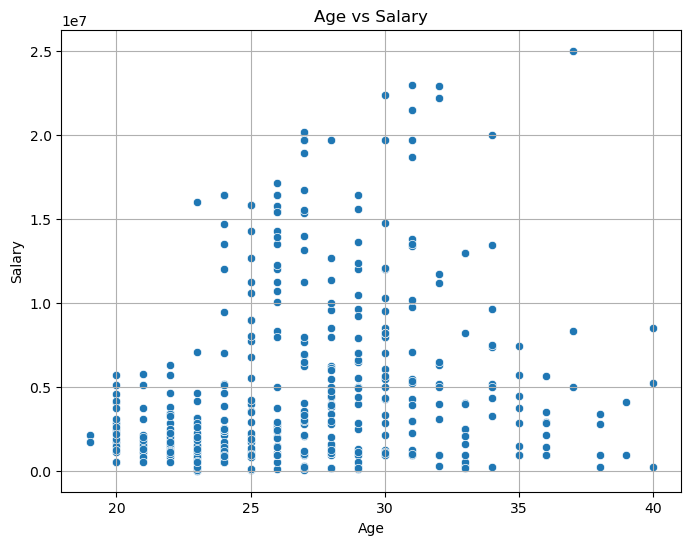

In [8]:
#Investigate if there's any correlation between age and salary, and represent it visually.

import matplotlib.pyplot as plt
import seaborn as sns
correlation = df["Age"].corr(df["Salary"])
print(f"Correlation between Age and Salary: {correlation:.2f}")
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Salary")
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

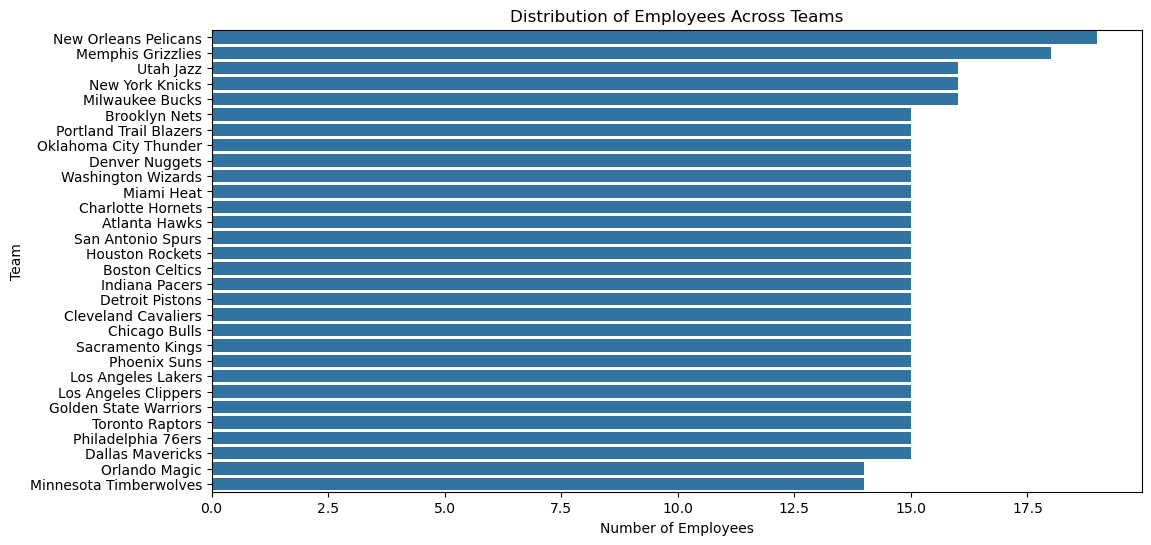

In [9]:
#Graphical Representation:
#For each of the five analysis tasks above, create appropriate visualizations to present your findings effectively.

plt.figure(figsize=(12,6))
sns.countplot(data=df, y="Team", order=df["Team"].value_counts().index)
plt.title("Distribution of Employees Across Teams")
plt.xlabel("Number of Employees")
plt.ylabel("Team")
plt.show()

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


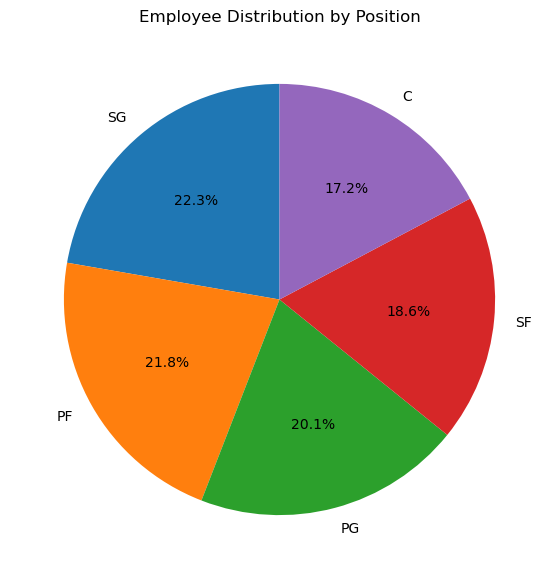

In [14]:
position_count = df["Position"].value_counts()
print(position_count)
plt.figure(figsize=(7,7))
plt.pie(
    position_count,
    labels=position_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Employee Distribution by Position")
plt.show()

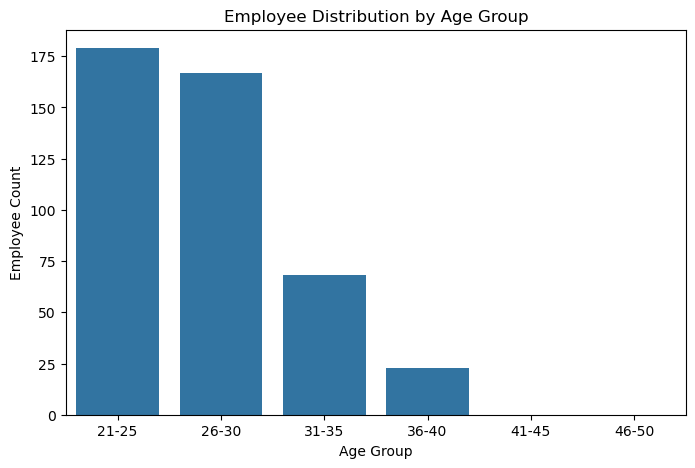

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="Age Group",
              order=labels)

plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employee Count")
plt.show()

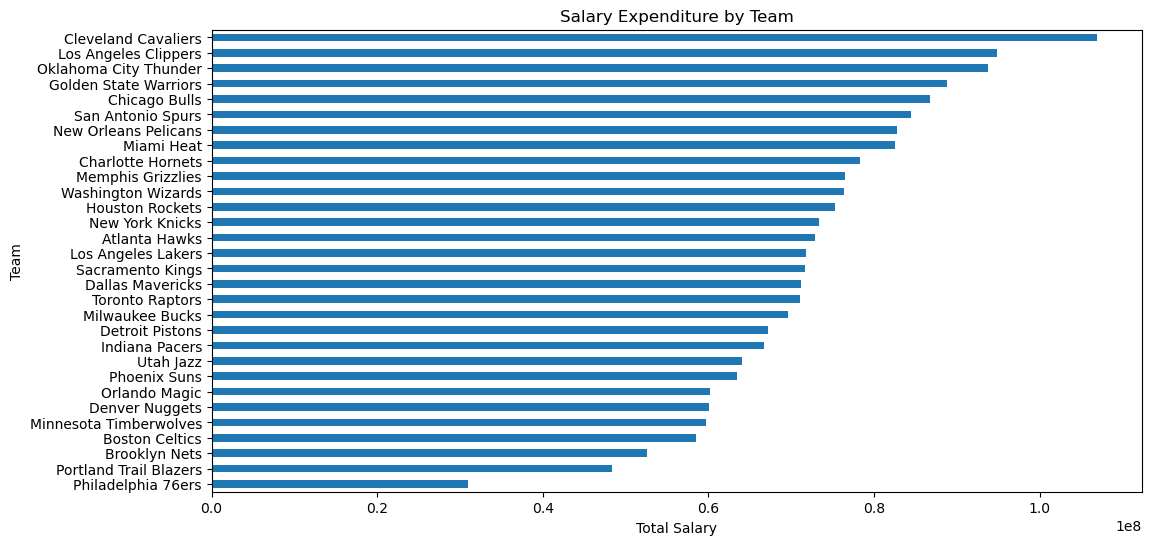

In [16]:
plt.figure(figsize=(12,6))
team_salary.sort_values().plot(kind="barh")

plt.title("Salary Expenditure by Team")
plt.xlabel("Total Salary")
plt.ylabel("Team")
plt.show()

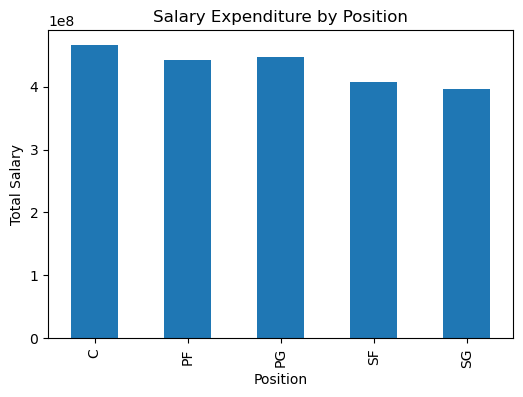

In [17]:
plt.figure(figsize=(6,4))
position_salary.plot(kind="bar")

plt.title("Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")
plt.show()

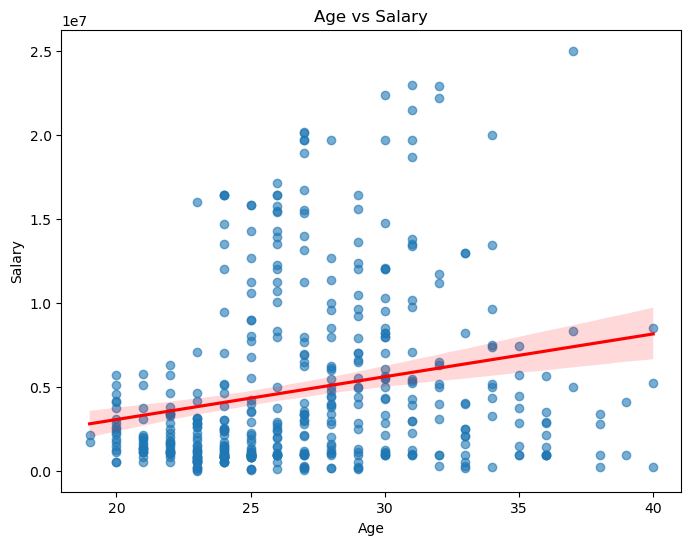

In [18]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,
            x="Age",
            y="Salary",
            scatter_kws={"alpha":0.6},
            line_kws={"color":"red"})

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

# Data Story

The analysis of the ABC Company employee dataset revealed several meaningful insights about the workforce.

* Employees are distributed across multiple teams, with some teams having significantly more employees than others. The percentage distribution shows that the workforce is not evenly divided among teams.

* The employees are spread across different positions such as Point Guard (PG), Shooting Guard (SG), Small Forward (SF), Power Forward (PF), and Center (C). Some positions have a higher number of employees, indicating greater staffing requirements for those roles.

* Most employees belong to the **26–30 years** age group, making it the predominant age category. This suggests that the organization has a relatively young workforce.

* Salary expenditure varies considerably across teams and positions. The analysis identified the team with the highest total salary expenditure and showed that one position accounts for the largest share of salary expenses, indicating that compensation is influenced by both team composition and job role.

* The correlation analysis between age and salary revealed a **very weak or negligible linear relationship**. The scatter plot showed no clear upward or downward trend, suggesting that age alone is not a strong predictor of salary. Other factors such as experience, position, performance, or team are likely to have a greater impact on employee compensation.

Overall, the analysis provides valuable insights into employee distribution, workforce composition, salary allocation, and the relationship between employee characteristics and compensation. These findings can help the organization understand its workforce structure and support informed decision-making regarding human resource planning and salary management.
